In [10]:
# Import Libraries
from pgmpy.models import DiscreteBayesianNetwork # network
from pgmpy.factors.discrete import TabularCPD # CPT
from pgmpy.inference import VariableElimination # Validation
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Define Network Structure
network = [('Cloudy', 'Rain'),
           ('Cloudy', 'Sprinkler'),
           ('Rain', 'WetGrass'),
           ('Sprinkler', 'WetGrass')]

In [3]:
# Bayesian Network

model = DiscreteBayesianNetwork(network)

In [4]:
# Define CPT

cpt_cloudy = TabularCPD(variable='Cloudy', variable_card=2, values=[[0.5], [0.5]])

cpt_rain = TabularCPD(variable='Rain', variable_card=2, values=[[0.8, 0.2], [0.2, 0.8]], evidence=['Cloudy'], evidence_card=[2])

cpt_sprinkler = TabularCPD(variable='Sprinkler', variable_card=2, values=[[0.5, 0.9], [0.5, 0.1]], evidence=['Cloudy'], evidence_card=[2])

cpt_wet_grass = TabularCPD(variable='WetGrass', variable_card=2, values=[[0.99, 0.9, 0.8, 0.0], [0.01, 0.1, 0.2, 1.0]], evidence=['Rain', 'Sprinkler'], evidence_card=[2, 2])

In [5]:
# Add the CPT to the model

model.add_cpds(cpt_cloudy, cpt_rain, cpt_sprinkler, cpt_wet_grass)

In [6]:
# Query

# 1) Rain given wet grass
inference = VariableElimination(model)
prob_rain_given_wet_grass = inference.query(variables=['Rain'], evidence={'WetGrass':
1})
print(prob_rain_given_wet_grass)

+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.1220 |
+---------+-------------+
| Rain(1) |      0.8780 |
+---------+-------------+


In [7]:
# 2) Sprinkler given wet grass
prob_sprinkler_given_wet_grass = inference.query(variables=['Sprinkler'], evidence={'WetGrass':1})
print(prob_sprinkler_given_wet_grass)

+--------------+------------------+
| Sprinkler    |   phi(Sprinkler) |
+==============+==================+
| Sprinkler(0) |           0.4334 |
+--------------+------------------+
| Sprinkler(1) |           0.5666 |
+--------------+------------------+


In [8]:
# 3) wet grass given rain, sprinkler 0
prob_wet_grass_given_rain_sprinkler = inference.query(variables=['WetGrass'], evidence={'Rain':1, 'Sprinkler':0})
print(prob_wet_grass_given_rain_sprinkler)

+-------------+-----------------+
| WetGrass    |   phi(WetGrass) |
+=============+=================+
| WetGrass(0) |          0.8000 |
+-------------+-----------------+
| WetGrass(1) |          0.2000 |
+-------------+-----------------+


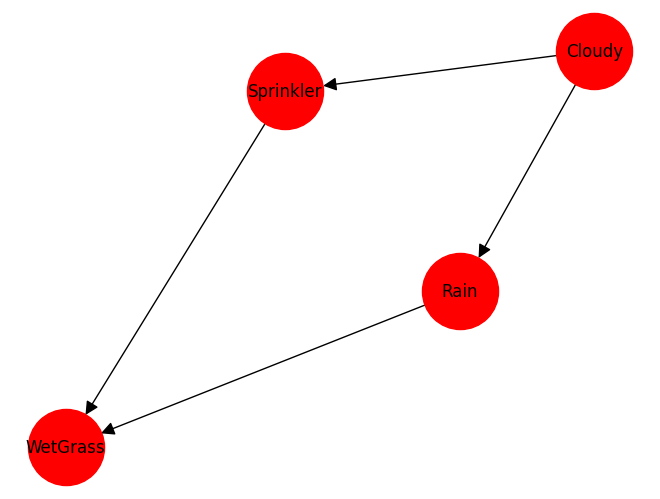

In [9]:
# Visualization

G = nx.DiGraph(network)
nx.draw(G, with_labels=True, node_size=3000, node_color="red", arrowsize=20)
plt.show()